DATA COLLECTION

In [1]:

import os
import time
import warnings
import pandas as pd
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import ta
 
warnings.filterwarnings("ignore")
 

In [2]:
TICKERS    = ["AAPL", "TSLA", "RELIANCE.NS"]
START_DATE = "2019-01-01"
END_DATE   = datetime.today().strftime("%Y-%m-%d")
OUTPUT_DIR = "data"

In [3]:
def fetch_stock_data(ticker, start, end):
    print(f"Downloading {ticker} ...")
    df = yf.download(ticker, start=start, end=end, auto_adjust=True)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df.index = pd.to_datetime(df.index)
    df.dropna(inplace=True)
    print(f"  ✓ {len(df)} rows downloaded")
    return df

# Test it
df_aapl = fetch_stock_data("AAPL", START_DATE, END_DATE)
df_aapl.tail()   # shows last 5 rows in notebook

[*********************100%***********************]  1 of 1 completed

  ✓ 1813 rows downloaded


Price,Close,High,Low,Open,Volume
Date,,,,,
2026-03-13,250.119995,256.329987,249.520004,255.479996,36930000
2026-03-16,252.820007,253.889999,249.880005,252.110001,32074200
2026-03-17,254.229996,255.130005,252.179993,252.960007,32361600
2026-03-18,249.940002,254.940002,249.000000,252.630005,35757900
2026-03-19,248.960007,251.830002,247.300003,249.399994,34568663


In [4]:
def add_technical_indicators(df):
    close = df["Close"].squeeze()

    df["SMA_20"]      = ta.trend.sma_indicator(close, window=20)
    df["SMA_50"]      = ta.trend.sma_indicator(close, window=50)
    df["EMA_20"]      = ta.trend.ema_indicator(close, window=20)
    df["RSI_14"]      = ta.momentum.rsi(close, window=14)

    macd = ta.trend.MACD(close)
    df["MACD"]        = macd.macd()
    df["MACD_Signal"] = macd.macd_signal()
    df["MACD_Hist"]   = macd.macd_diff()

    bb = ta.volatility.BollingerBands(close)
    df["BB_Upper"]    = bb.bollinger_hband()
    df["BB_Mid"]      = bb.bollinger_mavg()
    df["BB_Lower"]    = bb.bollinger_lband()

    df.dropna(inplace=True)
    print(f"  ✓ Indicators added. Columns: {list(df.columns)}")
    return df

df_aapl = add_technical_indicators(df_aapl)
df_aapl.tail()

  ✓ Indicators added. Columns: ['Close', 'High', 'Low', 'Open', 'Volume', 'SMA_20', 'SMA_50', 'EMA_20', 'RSI_14', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Upper', 'BB_Mid', 'BB_Lower']


Price,Close,High,Low,Open,Volume,SMA_20,SMA_50,EMA_20,RSI_14,MACD,MACD_Signal,MACD_Hist,BB_Upper,BB_Mid,BB_Lower
Date,,,,,,,,,,,,,,,
2026-03-13,250.119995,256.329987,249.520004,255.479996,36930000,262.749499,262.580556,261.650807,34.587558,-2.570190,-1.108276,-1.461914,274.250128,262.749499,251.248870
2026-03-16,252.820007,253.889999,249.880005,252.110001,32074200,262.601499,262.204839,260.809779,38.715201,-2.937502,-1.474121,-1.463381,274.525468,262.601499,250.677531
2026-03-17,254.229996,255.130005,252.179993,252.960007,32361600,262.118999,261.874306,260.183133,40.815515,-3.079328,-1.795162,-1.284166,274.566460,262.118999,249.671537
2026-03-18,249.940002,254.940002,249.000000,252.630005,35757900,261.398499,261.532903,259.207597,36.694893,-3.497575,-2.135645,-1.361930,274.871914,261.398499,247.925083
2026-03-19,248.960007,251.830002,247.300003,249.399994,34568663,260.817500,261.269809,258.231636,35.805608,-3.863580,-2.481232,-1.382348,275.343060,260.817500,246.291939


In [5]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch
import numpy as np
import requests
from datetime import datetime, timedelta
 
ALPHA_VANTAGE_KEY = "TBEBT3CFAEOZGUEU"  # 👈 paste your key here
 
def get_finbert_score(headlines, tokenizer, model):
    """scores headlines with finbert, returns avg score -1 to +1"""
    if not headlines:
        return None
    scores = []
    for headline in headlines:
        inputs = tokenizer(headline, return_tensors="pt", truncation=True, max_length=512, padding=True)
        with torch.no_grad():  # no gradient needed, saves memory
            outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1).squeeze().tolist()
        scores.append(probs[0] - probs[1])  # positive minus negative probability
    return sum(scores) / len(scores)
 
 
def get_price_derived_sentiment(df):
    """calculates sentiment from daily price movement as baseline"""
    daily_return = (df["Close"] - df["Open"]) / df["Open"]  # daily % change
    return np.tanh(daily_return * 10).squeeze()  # normalize to -1 to +1
 
 
def fetch_alpha_vantage_news(ticker, tokenizer, model):
    """
    fetches last 2 years of news from alpha vantage
    groups headlines by date and scores each date with finbert
    returns dict of {date: sentiment_score}
    """
    print(f"  Fetching 2 years of news from Alpha Vantage for {ticker} ...")
 
    # clean ticker for alpha vantage (remove .NS for indian stocks)
    clean_ticker = ticker.replace(".NS", "")
 
    # calculate date range - last 2 years
    end_date   = datetime.today()
    start_date = end_date - timedelta(days=730)  # 730 days = 2 years
 
    # alpha vantage news endpoint
    url = (
        f"https://www.alphavantage.co/query"
        f"?function=NEWS_SENTIMENT"
        f"&tickers={clean_ticker}"
        f"&time_from={start_date.strftime('%Y%m%dT0000')}"
        f"&time_to={end_date.strftime('%Y%m%dT2359')}"
        f"&limit=1000"           # max articles per request
        f"&apikey={ALPHA_VANTAGE_KEY}"
    )
 
    try:
        response = requests.get(url)
        data     = response.json()
 
        if "feed" not in data:
            print(f"  ⚠ No news feed returned. Check API key or ticker.")
            return {}
 
        articles = data["feed"]
        print(f"  ✓ {len(articles)} articles fetched from Alpha Vantage")
 
        # group headlines by date
        date_headlines = {}
        for article in articles:
            headline = article.get("title", "")
            pub_date = article.get("time_published", "")[:8]  # get YYYYMMDD
            pub_date = f"{pub_date[:4]}-{pub_date[4:6]}-{pub_date[6:]}"  # format to YYYY-MM-DD
 
            if headline and pub_date:
                date_headlines.setdefault(pub_date, []).append(headline)
 
        print(f"  ✓ Headlines found for {len(date_headlines)} unique dates")
 
        # score each date with finbert
        date_scores = {}
        for date, headlines in date_headlines.items():
            score = get_finbert_score(headlines, tokenizer, model)
            if score is not None:
                date_scores[date] = score
 
        print(f"  ✓ FinBERT scores calculated for {len(date_scores)} dates")
        return date_scores
 
    except Exception as e:
        print(f"  ⚠ Alpha Vantage fetch failed: {e}")
        return {}
 
 
def fetch_news_sentiment(ticker, df):
    """
    main function - combines everything:
    - price derived sentiment for all 5 years as baseline
    - alpha vantage real news for last 2 years scored by finbert
    - overwrites baseline with real scores where available
    """
    print(f"\n  [SENTIMENT] Processing {ticker} ...")
 
    # load finbert model
    print("  Loading FinBERT model ...")
    tokenizer = BertTokenizer.from_pretrained("ProsusAI/finbert")
    model     = BertForSequenceClassification.from_pretrained("ProsusAI/finbert")
    model.eval()  # evaluation mode not training mode
    print("  ✓ FinBERT loaded")
 
    # step 1 - fill all 5 years with price derived sentiment as baseline
    df["Sentiment"] = get_price_derived_sentiment(df)
    print(f"  ✓ Price-derived sentiment added for all {len(df)} trading days")
 
    # step 2 - fetch 2 years of real news and score with finbert
    date_scores = fetch_alpha_vantage_news(ticker, tokenizer, model)
 
    # step 3 - overwrite price derived scores with real finbert scores
    overwritten = 0
    for date, score in date_scores.items():
        mask = df.index.strftime("%Y-%m-%d") == date  # find matching row
        if mask.any():
            df.loc[mask, "Sentiment"] = score  # replace with real news score
            overwritten += 1
 
    print(f"\n  ✓ Summary for {ticker}:")
    print(f"    Total trading days     : {len(df)}")
    print(f"    Real news scored days  : {overwritten} (last 2 years)")
    print(f"    Price-derived days     : {len(df) - overwritten} (older history)")
    print(f"    Unique sentiment values: {df['Sentiment'].nunique()}")
    print(f"    Sentiment range        : {df['Sentiment'].min():.4f} to {df['Sentiment'].max():.4f}")
 
    return df
 
 
# test on aapl first
df_aapl = fetch_news_sentiment("AAPL", df_aapl)
df_aapl[["Close", "Sentiment"]].tail(15)
 



2026-03-20 16:35:25.301423: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.



  [SENTIMENT] Processing AAPL ...
  Loading FinBERT model ...
  ✓ FinBERT loaded
  ✓ Price-derived sentiment added for all 1764 trading days
  Fetching 2 years of news from Alpha Vantage for AAPL ...
  ✓ 1000 articles fetched from Alpha Vantage
  ✓ Headlines found for 34 unique dates
  ✓ FinBERT scores calculated for 34 dates

  ✓ Summary for AAPL:
    Total trading days     : 1764
    Real news scored days  : 23 (last 2 years)
    Price-derived days     : 1741 (older history)
    Unique sentiment values: 1762
    Sentiment range        : -0.6439 to 0.9161


Price,Close,Sentiment
Date,,
2026-02-27,264.179993,0.057384
2026-03-02,264.720001,0.121775
2026-03-03,263.750000,0.215037
2026-03-04,262.519989,0.133349
2026-03-05,260.290009,0.179688
2026-03-06,257.459991,0.152154
2026-03-09,259.880005,0.116856
2026-03-10,260.829987,0.040327
2026-03-11,260.809998,0.172660


In [6]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

all_data = {}

for ticker in TICKERS:
    print(f"\n{'='*50}\n  Processing: {ticker}\n{'='*50}")
    df = fetch_stock_data(ticker, START_DATE, END_DATE)
    df = add_technical_indicators(df)
    df = fetch_news_sentiment(ticker, df)  # ← now uses alpha vantage + finbert for all 3

    path = f"{OUTPUT_DIR}/{ticker.replace('.', '_')}_data.csv"
    df.to_csv(path)
    all_data[ticker] = df
    print(f"  ✓ Saved to {path}")
    time.sleep(1)

print("\n All 3 stocks done!")


  Processing: AAPL


[*********************100%***********************]  1 of 1 completed


  ✓ 1813 rows downloaded
  ✓ Indicators added. Columns: ['Close', 'High', 'Low', 'Open', 'Volume', 'SMA_20', 'SMA_50', 'EMA_20', 'RSI_14', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Upper', 'BB_Mid', 'BB_Lower']

  [SENTIMENT] Processing AAPL ...
  Loading FinBERT model ...
  ✓ FinBERT loaded
  ✓ Price-derived sentiment added for all 1764 trading days
  Fetching 2 years of news from Alpha Vantage for AAPL ...
  ✓ 1000 articles fetched from Alpha Vantage
  ✓ Headlines found for 34 unique dates
  ✓ FinBERT scores calculated for 34 dates

  ✓ Summary for AAPL:
    Total trading days     : 1764
    Real news scored days  : 23 (last 2 years)
    Price-derived days     : 1741 (older history)
    Unique sentiment values: 1762
    Sentiment range        : -0.6439 to 0.9161
  ✓ Saved to data/AAPL_data.csv

  Processing: TSLA


[*********************100%***********************]  1 of 1 completed


  ✓ 1813 rows downloaded
  ✓ Indicators added. Columns: ['Close', 'High', 'Low', 'Open', 'Volume', 'SMA_20', 'SMA_50', 'EMA_20', 'RSI_14', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Upper', 'BB_Mid', 'BB_Lower']

  [SENTIMENT] Processing TSLA ...
  Loading FinBERT model ...
  ✓ FinBERT loaded
  ✓ Price-derived sentiment added for all 1764 trading days
  Fetching 2 years of news from Alpha Vantage for TSLA ...
  ✓ 1000 articles fetched from Alpha Vantage
  ✓ Headlines found for 44 unique dates
  ✓ FinBERT scores calculated for 44 dates

  ✓ Summary for TSLA:
    Total trading days     : 1764
    Real news scored days  : 30 (last 2 years)
    Price-derived days     : 1734 (older history)
    Unique sentiment values: 1763
    Sentiment range        : -0.8562 to 0.9713
  ✓ Saved to data/TSLA_data.csv

  Processing: RELIANCE.NS


[*********************100%***********************]  1 of 1 completed


  ✓ 1784 rows downloaded
  ✓ Indicators added. Columns: ['Close', 'High', 'Low', 'Open', 'Volume', 'SMA_20', 'SMA_50', 'EMA_20', 'RSI_14', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Upper', 'BB_Mid', 'BB_Lower']

  [SENTIMENT] Processing RELIANCE.NS ...
  Loading FinBERT model ...
  ✓ FinBERT loaded
  ✓ Price-derived sentiment added for all 1735 trading days
  Fetching 2 years of news from Alpha Vantage for RELIANCE.NS ...
  ✓ 0 articles fetched from Alpha Vantage
  ✓ Headlines found for 0 unique dates
  ✓ FinBERT scores calculated for 0 dates

  ✓ Summary for RELIANCE.NS:
    Total trading days     : 1735
    Real news scored days  : 0 (last 2 years)
    Price-derived days     : 1735 (older history)
    Unique sentiment values: 1733
    Sentiment range        : -0.7679 to 0.8423
  ✓ Saved to data/RELIANCE_NS_data.csv

 All 3 stocks done!


In [7]:
def fetch_reliance_news(df):
    """
    For RELIANCE.NS we use yfinance news + finbert
    since alpha vantage doesn't cover indian stocks
    """
    print("  Fetching RELIANCE news from yfinance ...")
    
    tokenizer = BertTokenizer.from_pretrained("ProsusAI/finbert")
    model = BertForSequenceClassification.from_pretrained("ProsusAI/finbert")
    model.eval()

    # fill all dates with price derived sentiment first
    df["Sentiment"] = get_price_derived_sentiment(df)

    try:
        news_list = yf.Ticker("RELIANCE.NS").news
        date_headlines = {}

        for item in news_list:
            headline = item.get("content", {}).get("title") or item.get("title", "")
            pub_date = item.get("content", {}).get("pubDate", "")[:10]
            if not pub_date:
                ts = item.get("providerPublishTime", None)
                if ts:
                    pub_date = pd.to_datetime(ts, unit="s").strftime("%Y-%m-%d")
            if headline and pub_date:
                date_headlines.setdefault(pub_date, []).append(headline)

        # score with finbert and overwrite
        for date, headlines in date_headlines.items():
            score = get_finbert_score(headlines, tokenizer, model)
            if score is not None:
                mask = df.index.strftime("%Y-%m-%d") == date
                if mask.any():
                    df.loc[mask, "Sentiment"] = score

        print(f"  ✓ yfinance headlines applied for {len(date_headlines)} dates")

    except Exception as e:
        print(f"  ⚠ yfinance news failed ({e}), using price-derived only")

    print(f"  Unique sentiment values: {df['Sentiment'].nunique()}")
    return df


# fix reliance sentiment and resave
reliance_df = all_data["RELIANCE.NS"]
reliance_df = fetch_reliance_news(reliance_df)
reliance_df.to_csv("data/RELIANCE_NS_data.csv")
all_data["RELIANCE.NS"] = reliance_df
print("✅ RELIANCE.NS sentiment fixed and resaved!")

  Fetching RELIANCE news from yfinance ...
  ✓ yfinance headlines applied for 6 dates
  Unique sentiment values: 1733
✅ RELIANCE.NS sentiment fixed and resaved!


In [8]:

for ticker, df in all_data.items():
    print(f"\n{ticker}: {df.shape[0]} rows × {df.shape[1]} columns")
    display(df.head(3))


AAPL: 1764 rows × 16 columns


Price,Close,High,Low,Open,Volume,SMA_20,SMA_50,EMA_20,RSI_14,MACD,MACD_Signal,MACD_Hist,BB_Upper,BB_Mid,BB_Lower,Sentiment
Date,,,,,,,,,,,,,,,,
2019-03-14,43.820374,43.908623,43.541324,43.860919,94318000,41.694338,39.373997,41.738311,75.107596,0.949050,0.847050,0.102000,43.449185,41.694338,39.939491,-0.009244
2019-03-15,44.390396,44.678988,43.822759,44.087498,156171600,41.877033,39.511731,41.990890,77.641931,1.045153,0.886671,0.158483,43.930379,41.877033,39.823686,0.068596
2019-03-18,44.843548,44.931793,44.311681,44.314068,104879200,42.086917,39.733241,42.262572,79.434488,1.144686,0.938274,0.206412,44.431467,42.086917,39.742366,0.118918



TSLA: 1764 rows × 16 columns


Price,Close,High,Low,Open,Volume,SMA_20,SMA_50,EMA_20,RSI_14,MACD,MACD_Signal,MACD_Hist,BB_Upper,BB_Mid,BB_Lower,Sentiment
Date,,,,,,,,,,,,,,,,
2019-03-14,19.330667,19.692667,19.219334,19.496668,106551000,19.613000,20.509440,19.551159,46.130597,-0.411236,-0.412326,0.001090,21.219141,19.613000,18.006859,-0.084938
2019-03-15,18.362000,18.914667,18.293333,18.900667,221782500,19.518533,20.463187,19.437906,38.932252,-0.455668,-0.420995,-0.034673,21.184517,19.518533,17.852550,-0.277526
2019-03-18,17.966000,18.536667,17.820000,18.400000,154215000,19.390567,20.422027,19.297724,36.429587,-0.516876,-0.440171,-0.076705,21.119538,19.390567,17.661595,-0.231591



RELIANCE.NS: 1735 rows × 16 columns


Price,Close,High,Low,Open,Volume,SMA_20,SMA_50,EMA_20,RSI_14,MACD,MACD_Signal,MACD_Hist,BB_Upper,BB_Mid,BB_Lower,Sentiment
Date,,,,,,,,,,,,,,,,
2019-03-13,599.122620,604.770063,590.584695,594.542387,24577591,556.534079,539.631429,561.896781,73.970050,11.158722,7.052127,4.106595,588.735659,556.534079,524.332499,0.076886
2019-03-14,596.565674,605.659467,594.142127,600.212097,22753310,558.427325,541.592931,565.198580,71.870462,12.533861,8.148474,4.385387,595.062978,558.427325,521.791673,-0.060678
2019-03-15,587.716553,604.236536,583.069590,598.099894,34764353,560.594055,543.507297,567.343149,64.994720,12.762501,9.071279,3.691222,598.745195,560.594055,522.442916,-0.171882


FEATURE ENGINEERING


In [9]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pickle

In [10]:
WINDOW_SIZE  = 90    # use last 60 days to predict next day
TARGET_COL   = "Close"
TEST_SPLIT   = 0.1   # 10% test
VAL_SPLIT    = 0.1   # 10% validation
TRAIN_SPLIT  = 0.8   # 80% training
FEATURE_COLS = [
    "Close", "High", "Low", "Open", "Volume",
    "SMA_20", "SMA_50", "EMA_20", "RSI_14",
    "MACD", "MACD_Signal", "MACD_Hist",
    "BB_Upper", "BB_Mid", "BB_Lower", "Sentiment"
]

In [11]:
def normalize_data(df, ticker):
    """
    Normalizes all feature columns using MinMaxScaler.
    Scaler is fit ONLY on training data to prevent data leakage.
    Saves scaler to disk so we can inverse transform predictions later.
    """
    print(f"\n[NORMALIZE] Processing {ticker} ...")

    # keep only feature columns
    data = df[FEATURE_COLS].copy()

    # calculate split indices
    n         = len(data)
    train_end = int(n * TRAIN_SPLIT)
    val_end   = int(n * (TRAIN_SPLIT + VAL_SPLIT))

    # split raw data BEFORE scaling
    train_data = data.iloc[:train_end]       # 80% first
    val_data   = data.iloc[train_end:val_end] # next 10%
    test_data  = data.iloc[val_end:]          # last 10%

    print(f"  Train: {len(train_data)} rows ({train_data.index[0].date()} to {train_data.index[-1].date()})")
    print(f"  Val  : {len(val_data)} rows ({val_data.index[0].date()} to {val_data.index[-1].date()})")
    print(f"  Test : {len(test_data)} rows ({test_data.index[0].date()} to {test_data.index[-1].date()})")

    # fit scaler ONLY on training data ← prevents data leakage
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaler.fit(train_data)   # learn min/max from training data only

    # transform all splits using training scaler
    train_scaled = scaler.transform(train_data)
    val_scaled   = scaler.transform(val_data)
    test_scaled  = scaler.transform(test_data)

    # save scaler to disk for later inverse transforming predictions
    os.makedirs("scalers", exist_ok=True)
    scaler_path = f"scalers/{ticker.replace('.', '_')}_scaler.pkl"
    with open(scaler_path, "wb") as f:
        pickle.dump(scaler, f)
    print(f"  ✓ Scaler saved → {scaler_path}")

    return train_scaled, val_scaled, test_scaled, scaler

In [12]:
def create_sequences(data, window_size, target_col_idx):
    """
    Creates sliding window sequences for LSTM input.

    Example with window_size=3:
      Day1, Day2, Day3 → predict Day4
      Day2, Day3, Day4 → predict Day5
      Day3, Day4, Day5 → predict Day6

    Args:
        data          : scaled numpy array
        window_size   : how many past days to look at
        target_col_idx: index of Close column in features

    Returns:
        X : shape (samples, window_size, features) ← LSTM input
        y : shape (samples,)                       ← target prices
    """
    X, y = [], []

    for i in range(window_size, len(data)):
        X.append(data[i - window_size:i])   # last 60 days as input
        y.append(data[i, target_col_idx])    # next day close as target

    return np.array(X), np.array(y)

In [13]:
# index of Close column in FEATURE_COLS
TARGET_IDX = FEATURE_COLS.index(TARGET_COL)

# store everything for all 3 stocks
processed_data = {}

for ticker, df in all_data.items():
    print(f"\n{'='*50}\n  Feature Engineering: {ticker}\n{'='*50}")

    # step 1 - normalize
    train_scaled, val_scaled, test_scaled, scaler = normalize_data(df, ticker)

    # step 2 - create sequences
    X_train, y_train = create_sequences(train_scaled, WINDOW_SIZE, TARGET_IDX)
    X_val,   y_val   = create_sequences(val_scaled,   WINDOW_SIZE, TARGET_IDX)
    X_test,  y_test  = create_sequences(test_scaled,  WINDOW_SIZE, TARGET_IDX)

    # store in dict
    processed_data[ticker] = {
        "X_train": X_train, "y_train": y_train,
        "X_val"  : X_val,   "y_val"  : y_val,
        "X_test" : X_test,  "y_test" : y_test,
        "scaler" : scaler
    }

    print(f"\n  ✓ Shapes for {ticker}:")
    print(f"    X_train : {X_train.shape}  ← (samples, 60 days, 16 features)")
    print(f"    y_train : {y_train.shape}")
    print(f"    X_val   : {X_val.shape}")
    print(f"    y_val   : {y_val.shape}")
    print(f"    X_test  : {X_test.shape}")
    print(f"    y_test  : {y_test.shape}")

print("\n✅ Feature engineering done for all 3 stocks!")


  Feature Engineering: AAPL

[NORMALIZE] Processing AAPL ...
  Train: 1411 rows (2019-03-14 to 2024-10-18)
  Val  : 176 rows (2024-10-21 to 2025-07-07)
  Test : 177 rows (2025-07-08 to 2026-03-19)
  ✓ Scaler saved → scalers/AAPL_scaler.pkl

  ✓ Shapes for AAPL:
    X_train : (1321, 90, 16)  ← (samples, 60 days, 16 features)
    y_train : (1321,)
    X_val   : (86, 90, 16)
    y_val   : (86,)
    X_test  : (87, 90, 16)
    y_test  : (87,)

  Feature Engineering: TSLA

[NORMALIZE] Processing TSLA ...
  Train: 1411 rows (2019-03-14 to 2024-10-18)
  Val  : 176 rows (2024-10-21 to 2025-07-07)
  Test : 177 rows (2025-07-08 to 2026-03-19)
  ✓ Scaler saved → scalers/TSLA_scaler.pkl

  ✓ Shapes for TSLA:
    X_train : (1321, 90, 16)  ← (samples, 60 days, 16 features)
    y_train : (1321,)
    X_val   : (86, 90, 16)
    y_val   : (86,)
    X_test  : (87, 90, 16)
    y_test  : (87,)

  Feature Engineering: RELIANCE.NS

[NORMALIZE] Processing RELIANCE.NS ...
  Train: 1388 rows (2019-03-13 to 2024

In [14]:
# this cell proves there is no data leakage
print("DATA LEAKAGE CHECK")
print("="*50)

for ticker, df in all_data.items():
    n         = len(df)
    train_end = int(n * TRAIN_SPLIT)
    val_end   = int(n * (TRAIN_SPLIT + VAL_SPLIT))

    train_dates = df.index[:train_end]
    val_dates   = df.index[train_end:val_end]
    test_dates  = df.index[val_end:]

    # check no overlap between splits
    train_val_overlap  = len(set(train_dates) & set(val_dates))
    val_test_overlap   = len(set(val_dates)   & set(test_dates))
    train_test_overlap = len(set(train_dates) & set(test_dates))

    print(f"\n{ticker}:")
    print(f"  Train ends   : {train_dates[-1].date()}")
    print(f"  Val starts   : {val_dates[0].date()}")
    print(f"  Val ends     : {val_dates[-1].date()}")
    print(f"  Test starts  : {test_dates[0].date()}")
    print(f"  Train/Val overlap  : {train_val_overlap}")
    print(f"  Val/Test overlap   : {val_test_overlap} ")
    print(f"  Train/Test overlap : {train_test_overlap} ")
    print(f"  Scaler fit on      : TRAIN ONLY  (no leakage)")




DATA LEAKAGE CHECK

AAPL:
  Train ends   : 2024-10-18
  Val starts   : 2024-10-21
  Val ends     : 2025-07-07
  Test starts  : 2025-07-08
  Train/Val overlap  : 0
  Val/Test overlap   : 0 
  Train/Test overlap : 0 
  Scaler fit on      : TRAIN ONLY  (no leakage)



TSLA:
  Train ends   : 2024-10-18
  Val starts   : 2024-10-21
  Val ends     : 2025-07-07
  Test starts  : 2025-07-08
  Train/Val overlap  : 0
  Val/Test overlap   : 0 
  Train/Test overlap : 0 
  Scaler fit on      : TRAIN ONLY  (no leakage)

RELIANCE.NS:
  Train ends   : 2024-10-25
  Val starts   : 2024-10-28
  Val ends     : 2025-07-08
  Test starts  : 2025-07-09
  Train/Val overlap  : 0
  Val/Test overlap   : 0 
  Train/Test overlap : 0 
  Scaler fit on      : TRAIN ONLY  (no leakage)


LSTM TRAIN & TEST

In [15]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    LSTM, Bidirectional, Dense, Dropout,
    Input, MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math
os.makedirs("models", exist_ok=True)

In [16]:
def build_lstm_model(window_size, n_features):
    """
    Standard stacked LSTM with 2 layers.
    2 layers is enough for most time series tasks.
    """
    inputs = Input(shape=(window_size, n_features))

    x = LSTM(128, return_sequences=True)(inputs)  # first LSTM layer
    x = Dropout(0.2)(x)                           # 20% dropout

    x = LSTM(64, return_sequences=False)(x)        # second LSTM layer
    x = Dropout(0.2)(x)

    x = Dense(32, activation="relu")(x)
    outputs = Dense(1)(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss="mse"
    )
    return model

In [17]:
def build_advanced_model(window_size, n_features):
    """
    Bidirectional LSTM with Attention mechanism.
    Reads sequence forward and backward + focuses on important days.
    """
    inputs = Input(shape=(window_size, n_features))

    x = Bidirectional(LSTM(128, return_sequences=True))(inputs)
    x = Dropout(0.3)(x)

    x = Bidirectional(LSTM(64, return_sequences=True))(x)
    x = Dropout(0.3)(x)

    attn = MultiHeadAttention(num_heads=4, key_dim=32)(x, x)
    x    = LayerNormalization()(attn + x)

    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation="relu")(x)
    x = Dropout(0.2)(x)
    x = Dense(32, activation="relu")(x)
    outputs = Dense(1)(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss="mse"
    )
    return model

In [18]:
def train_model(model, X_train, y_train, X_val, y_val, model_path):
    """
    Trains with EarlyStopping, ModelCheckpoint and ReduceLROnPlateau.
    """
    callbacks = [
        EarlyStopping(
            monitor              = "val_loss",
            patience             = 20,
            restore_best_weights = True
        ),
        ModelCheckpoint(
            filepath       = model_path,
            monitor        = "val_loss",
            save_best_only = True,
            verbose        = 1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor  = "val_loss",
            factor   = 0.5,       # halve lr when stuck
            patience = 5,
            min_lr   = 0.00001
        )
    ]

    history = model.fit(
        X_train, y_train,
        validation_data = (X_val, y_val),
        epochs          = 150,
        batch_size      = 32,
        callbacks       = callbacks,
        verbose         = 1
    )
    return history

In [19]:
def calculate_metrics(y_true, y_pred, label=""):
    """Calculates RMSE, MAE, MAPE on real price scale."""
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"  {label} Metrics:")
    print(f"    RMSE : {rmse:.4f}")
    print(f"    MAE  : {mae:.4f}")
    print(f"    MAPE : {mape:.4f}%")
    return rmse, mae, mape

In [20]:
def predict_next_7_days(model, last_sequence, scaler, n_features, target_idx):
    """
    Predicts next 7 days recursively.
    Uses each predicted day as input for next prediction.
    """
    predictions = []
    current_seq = last_sequence.copy()  # start with last 60 days

    for _ in range(7):
        pred = model.predict(
            current_seq.reshape(1, current_seq.shape[0], n_features),
            verbose=0
        )[0][0]
        predictions.append(pred)

        # create new row with predicted close, keep other features same as last day
        new_row             = current_seq[-1].copy()
        new_row[target_idx] = pred

        # slide window forward by 1 day
        current_seq = np.vstack([current_seq[1:], new_row])

    # inverse transform to get actual price values
    dummy = np.zeros((7, n_features))
    dummy[:, target_idx] = predictions
    actual_prices = scaler.inverse_transform(dummy)[:, target_idx]

    return actual_prices

In [21]:
def calculate_metrics(y_true, y_pred, label=""):
    """Calculates RMSE, MAE, MAPE on real price scale."""
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"  {label} Metrics:")
    print(f"    RMSE : {rmse:.4f}")
    print(f"    MAE  : {mae:.4f}")
    print(f"    MAPE : {mape:.4f}%")
    return rmse, mae, mape

In [22]:

def predict_next_7_days(model, last_sequence, scaler, n_features, target_idx):
    """
    Predicts next 7 days recursively.
    Each predicted day becomes input for next prediction.
    """
    predictions = []
    current_seq = last_sequence.copy()

    for _ in range(7):
        pred = model.predict(
            current_seq.reshape(1, current_seq.shape[0], n_features),
            verbose=0
        )[0][0]
        predictions.append(pred)

        new_row             = current_seq[-1].copy()
        new_row[target_idx] = pred
        current_seq         = np.vstack([current_seq[1:], new_row])

    # inverse transform to real prices
    dummy = np.zeros((7, n_features))
    dummy[:, target_idx] = predictions
    return scaler.inverse_transform(dummy)[:, target_idx]

In [23]:
all_metrics = {}

for ticker, data in processed_data.items():
    print(f"\n{'='*50}\n  Training: {ticker}\n{'='*50}")

    X_train      = data["X_train"]
    y_train      = data["y_train"]
    X_val        = data["X_val"]
    y_val        = data["y_val"]
    X_test       = data["X_test"]
    y_test       = data["y_test"]
    scaler       = data["scaler"]
    n_features   = X_train.shape[2]
    clean_ticker = ticker.replace(".", "_")

    # train standard lstm
    print("\n  [1] Training Standard LSTM ...")
    lstm_model = build_lstm_model(WINDOW_SIZE, n_features)
    lstm_path  = f"models/{clean_ticker}_lstm.keras"
    train_model(lstm_model, X_train, y_train, X_val, y_val, lstm_path)

    # train advanced model
    print("\n  [2] Training BiLSTM + Attention ...")
    adv_model = build_advanced_model(WINDOW_SIZE, n_features)
    adv_path  = f"models/{clean_ticker}_advanced.keras"
    train_model(adv_model, X_train, y_train, X_val, y_val, adv_path)

    # evaluate
    print(f"\n  [3] Evaluating ...")
    def inverse_close(scaled_vals):
        dummy = np.zeros((len(scaled_vals), n_features))
        dummy[:, TARGET_IDX] = scaled_vals
        return scaler.inverse_transform(dummy)[:, TARGET_IDX]

    lstm_preds = lstm_model.predict(X_test, verbose=0).flatten()
    adv_preds  = adv_model.predict(X_test,  verbose=0).flatten()
    lstm_real  = inverse_close(lstm_preds)
    adv_real   = inverse_close(adv_preds)
    y_real     = inverse_close(y_test)

    lstm_metrics = calculate_metrics(y_real, lstm_real, "Standard LSTM")
    adv_metrics  = calculate_metrics(y_real, adv_real,  "BiLSTM+Attention")

    # next 7 days
    last_seq   = data["X_test"][-1]
    next7_lstm = predict_next_7_days(lstm_model, last_seq, scaler, n_features, TARGET_IDX)
    next7_adv  = predict_next_7_days(adv_model,  last_seq, scaler, n_features, TARGET_IDX)

    print(f"\n  Next 7 days Standard LSTM : {[round(p,2) for p in next7_lstm]}")
    print(f"  Next 7 days BiLSTM+Attn   : {[round(p,2) for p in next7_adv]}")

    all_metrics[ticker] = {
        "lstm"           : lstm_metrics,
        "advanced"       : adv_metrics,
        "lstm_preds_real": lstm_real,
        "adv_preds_real" : adv_real,
        "y_test_real"    : y_real,
        "next_7_lstm"    : next7_lstm,
        "next_7_adv"     : next7_adv
    }

# final summary
print(f"\n{'='*65}")
print("  FINAL METRICS SUMMARY")
print(f"{'='*65}")
print(f"  {'Stock':<15} {'Model':<25} {'RMSE':>8} {'MAE':>8} {'MAPE':>8}")
print(f"  {'-'*65}")

for ticker, metrics in all_metrics.items():
    r, m, p = metrics["lstm"]
    print(f"  {ticker:<15} {'Standard LSTM':<25} {r:>8.4f} {m:>8.4f} {p:>8.4f}%")
    r, m, p = metrics["advanced"]
    print(f"  {'':<15} {'BiLSTM+Attention':<25} {r:>8.4f} {m:>8.4f} {p:>8.4f}%")
    print(f"  {'-'*65}")

print("All done!")



"""
  FINAL METRICS SUMMARY
=================================================================
  Stock           Model                         RMSE      MAE     MAPE
  -----------------------------------------------------------------
  AAPL            Standard LSTM              37.0833  36.1111  13.4369%
                  BiLSTM+Attention           14.6738  11.9745   4.4067%
  -----------------------------------------------------------------
  TSLA            Standard LSTM              19.5396  16.1718   3.7114%
                  BiLSTM+Attention           42.8753  39.7881   9.1712%
  -----------------------------------------------------------------
  RELIANCE.NS     Standard LSTM              31.9058  26.3703   1.7983%
                  BiLSTM+Attention           47.6813  38.4963   2.6702%
  -----------------------------------------------------------------

"""


  Training: AAPL

  [1] Training Standard LSTM ...


2026-03-20 16:43:03.637838: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/150
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - loss: 0.0723
Epoch 1: val_loss improved from None to 0.00311, saving model to models/AAPL_lstm.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 21s 328ms/step - loss: 0.0289 - val_loss: 0.0031 - learning_rate: 5.0000e-04
Epoch 2/150
17/42 ━━━━━━━━━━━━━━━━━━━━ 5s 212ms/step - loss: 0.0077

KeyboardInterrupt: 

VISUALIZATIONS

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
os.makedirs("plots", exist_ok=True)

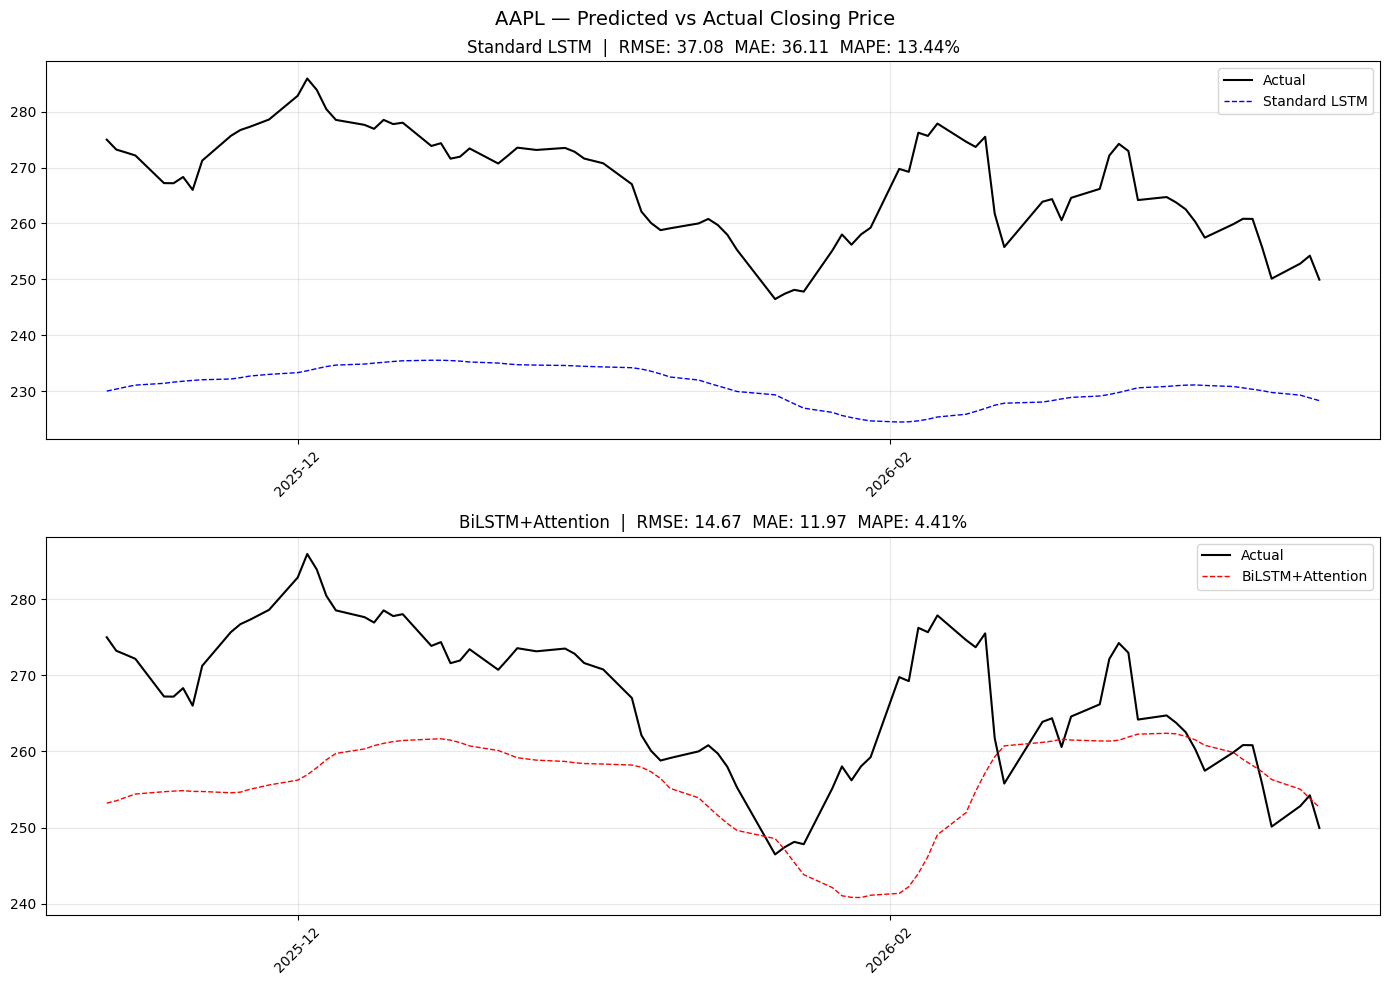

  ✓ Saved → plots/AAPL_predictions.png


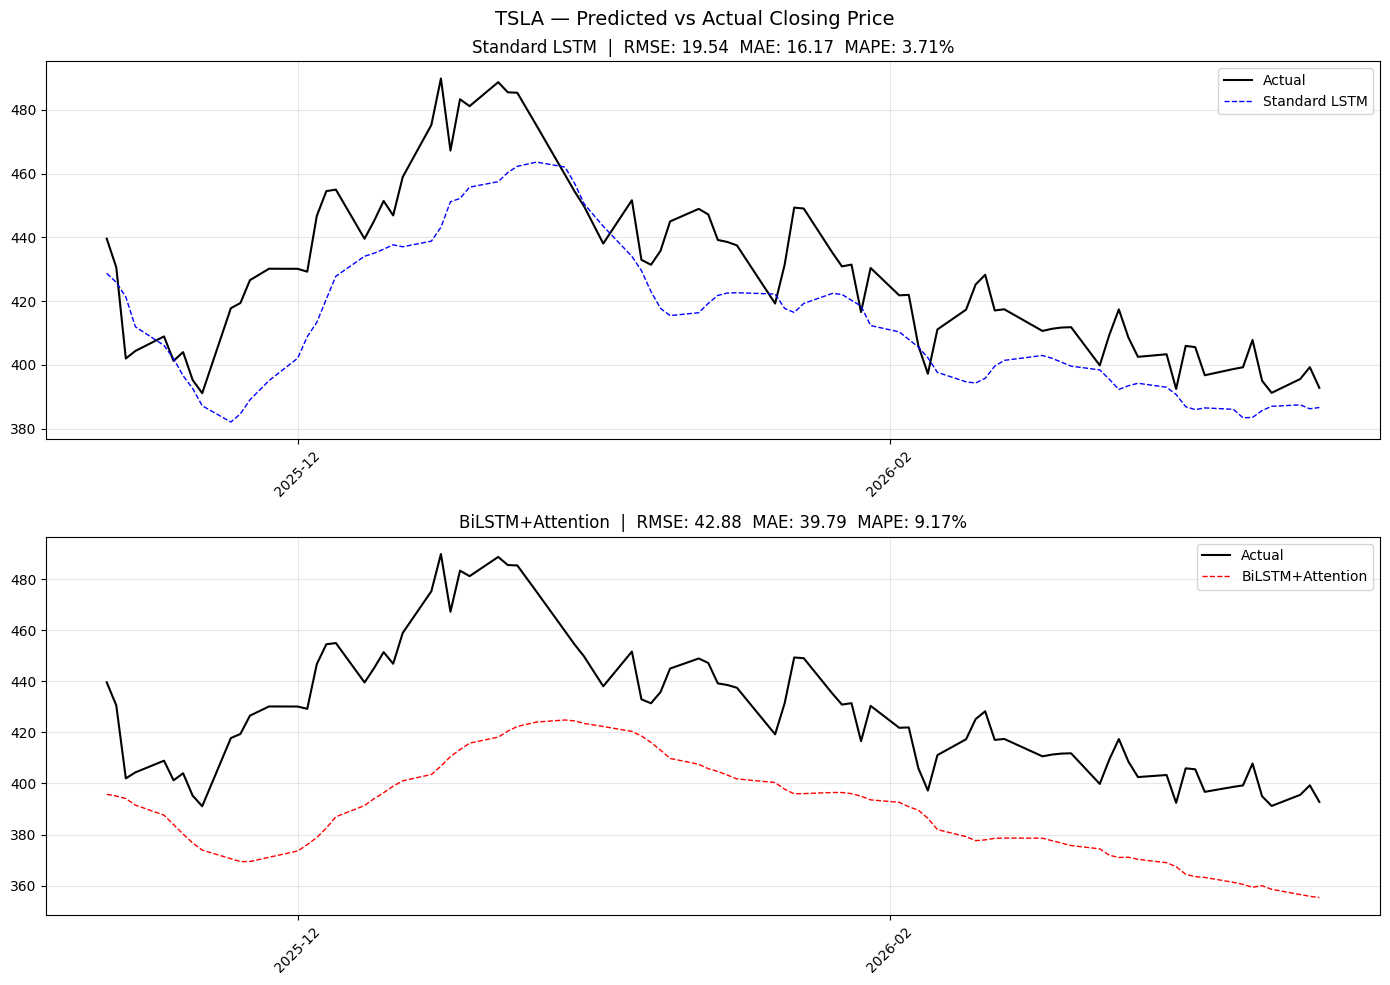

  ✓ Saved → plots/TSLA_predictions.png


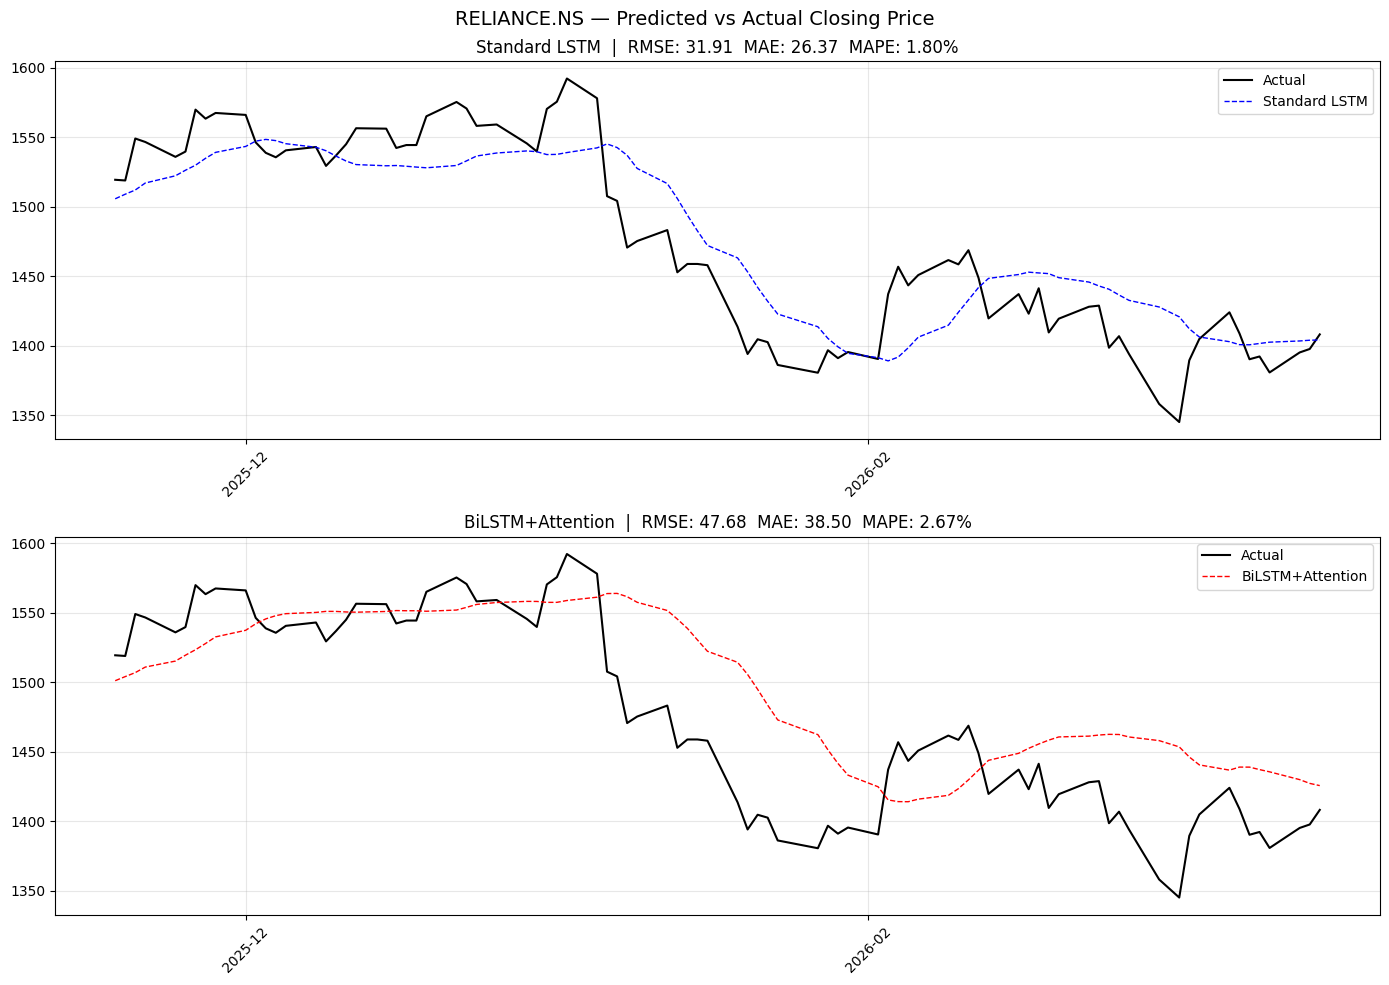

  ✓ Saved → plots/RELIANCE_NS_predictions.png


In [ ]:
def plot_predictions(ticker, metrics):
    y_real     = metrics["y_test_real"]
    lstm_preds = metrics["lstm_preds_real"]
    adv_preds  = metrics["adv_preds_real"]

    # get test dates from dataframe
    df         = all_data[ticker]
    n          = len(df)
    test_start = int(n * (TRAIN_SPLIT + VAL_SPLIT))
    test_dates = df.index[test_start + WINDOW_SIZE:]

    # trim to match prediction length
    test_dates = test_dates[:len(y_real)]

    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    fig.suptitle(f"{ticker} — Predicted vs Actual Closing Price", fontsize=14)

    # standard lstm plot
    axes[0].plot(test_dates, y_real,     label="Actual",        color="black", linewidth=1.5)
    axes[0].plot(test_dates, lstm_preds, label="Standard LSTM",  color="blue",  linewidth=1, linestyle="--")
    axes[0].set_title(f"Standard LSTM  |  RMSE: {metrics['lstm'][0]:.2f}  MAE: {metrics['lstm'][1]:.2f}  MAPE: {metrics['lstm'][2]:.2f}%")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

    # bilstm plot
    axes[1].plot(test_dates, y_real,    label="Actual",           color="black", linewidth=1.5)
    axes[1].plot(test_dates, adv_preds, label="BiLSTM+Attention", color="red",   linewidth=1, linestyle="--")
    axes[1].set_title(f"BiLSTM+Attention  |  RMSE: {metrics['advanced'][0]:.2f}  MAE: {metrics['advanced'][1]:.2f}  MAPE: {metrics['advanced'][2]:.2f}%")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

    plt.tight_layout()
    path = f"plots/{ticker.replace('.', '_')}_predictions.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  ✓ Saved → {path}")


for ticker, metrics in all_metrics.items():
    plot_predictions(ticker, metrics)

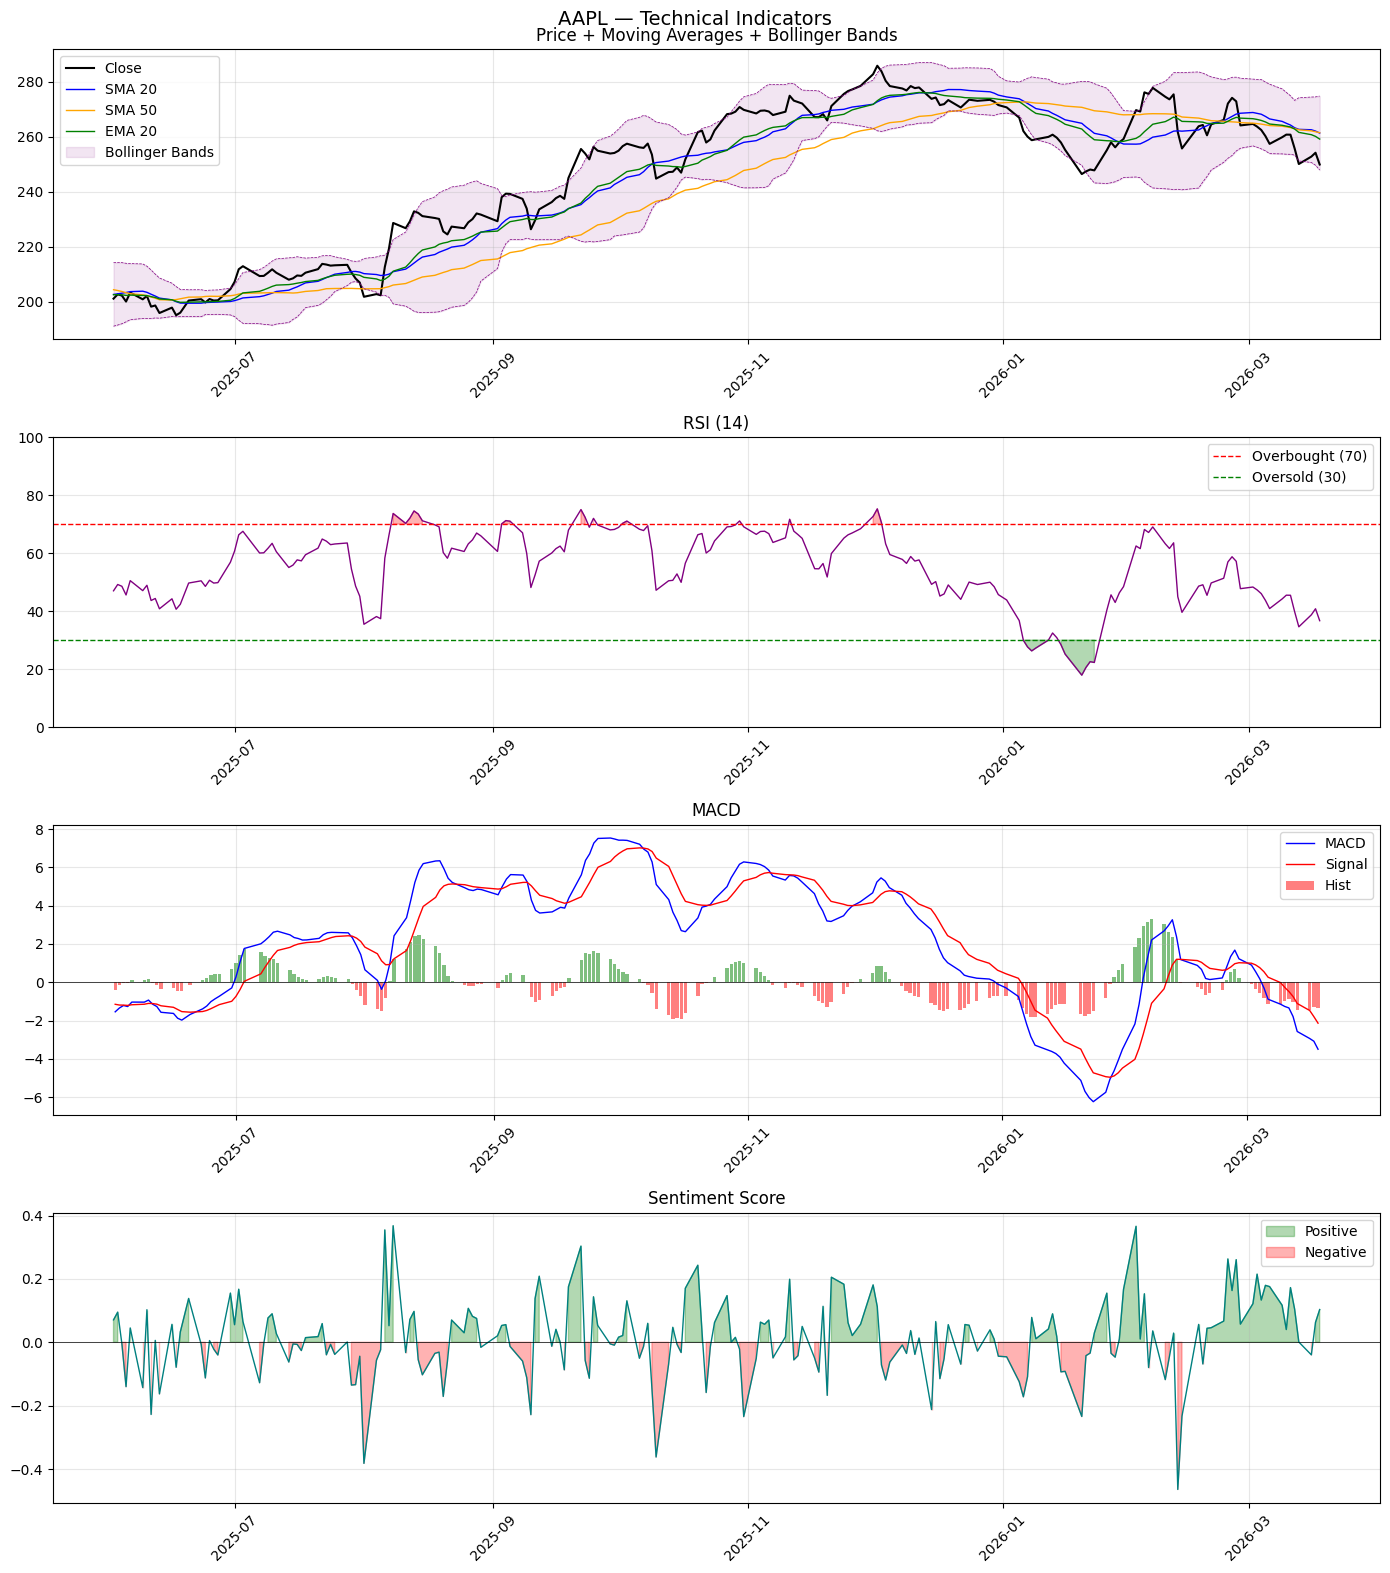

  ✓ Saved → plots/AAPL_indicators.png


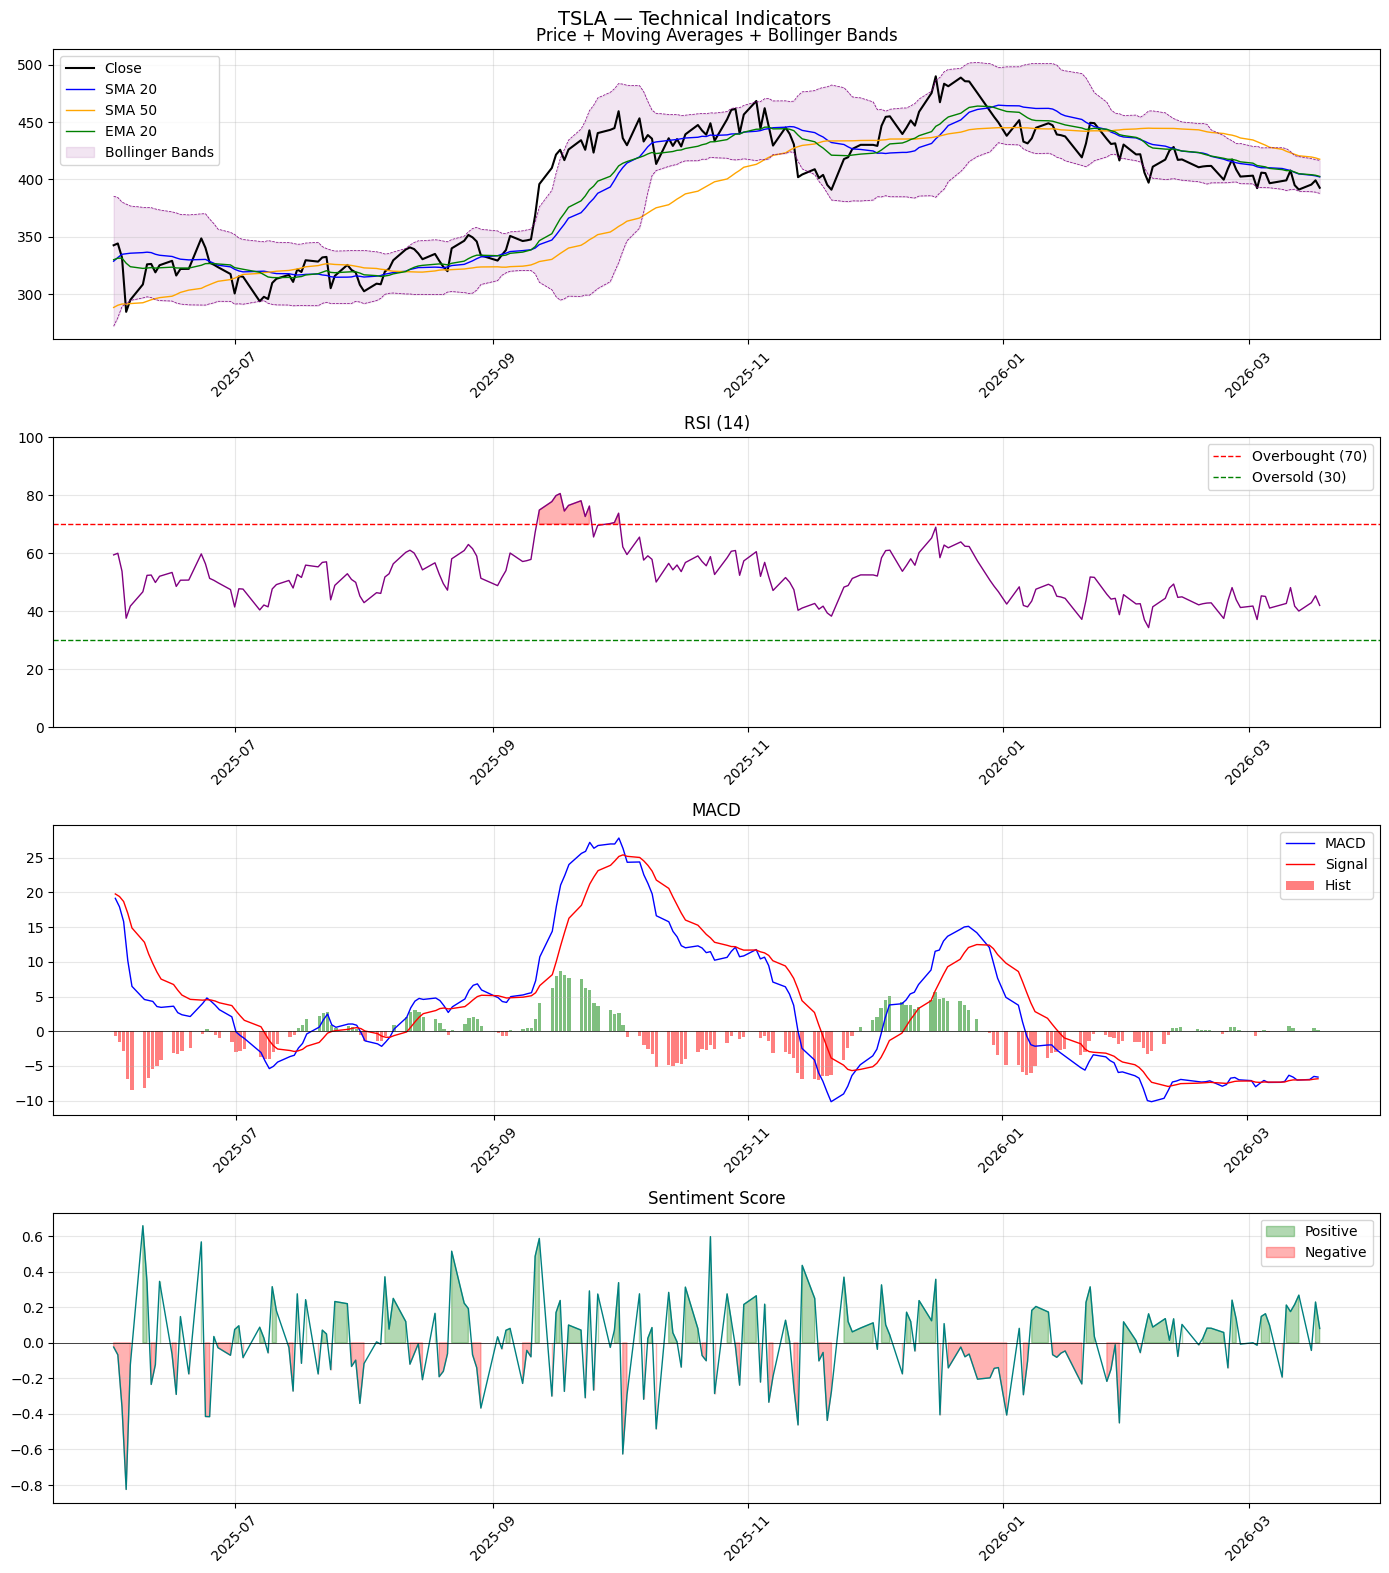

  ✓ Saved → plots/TSLA_indicators.png


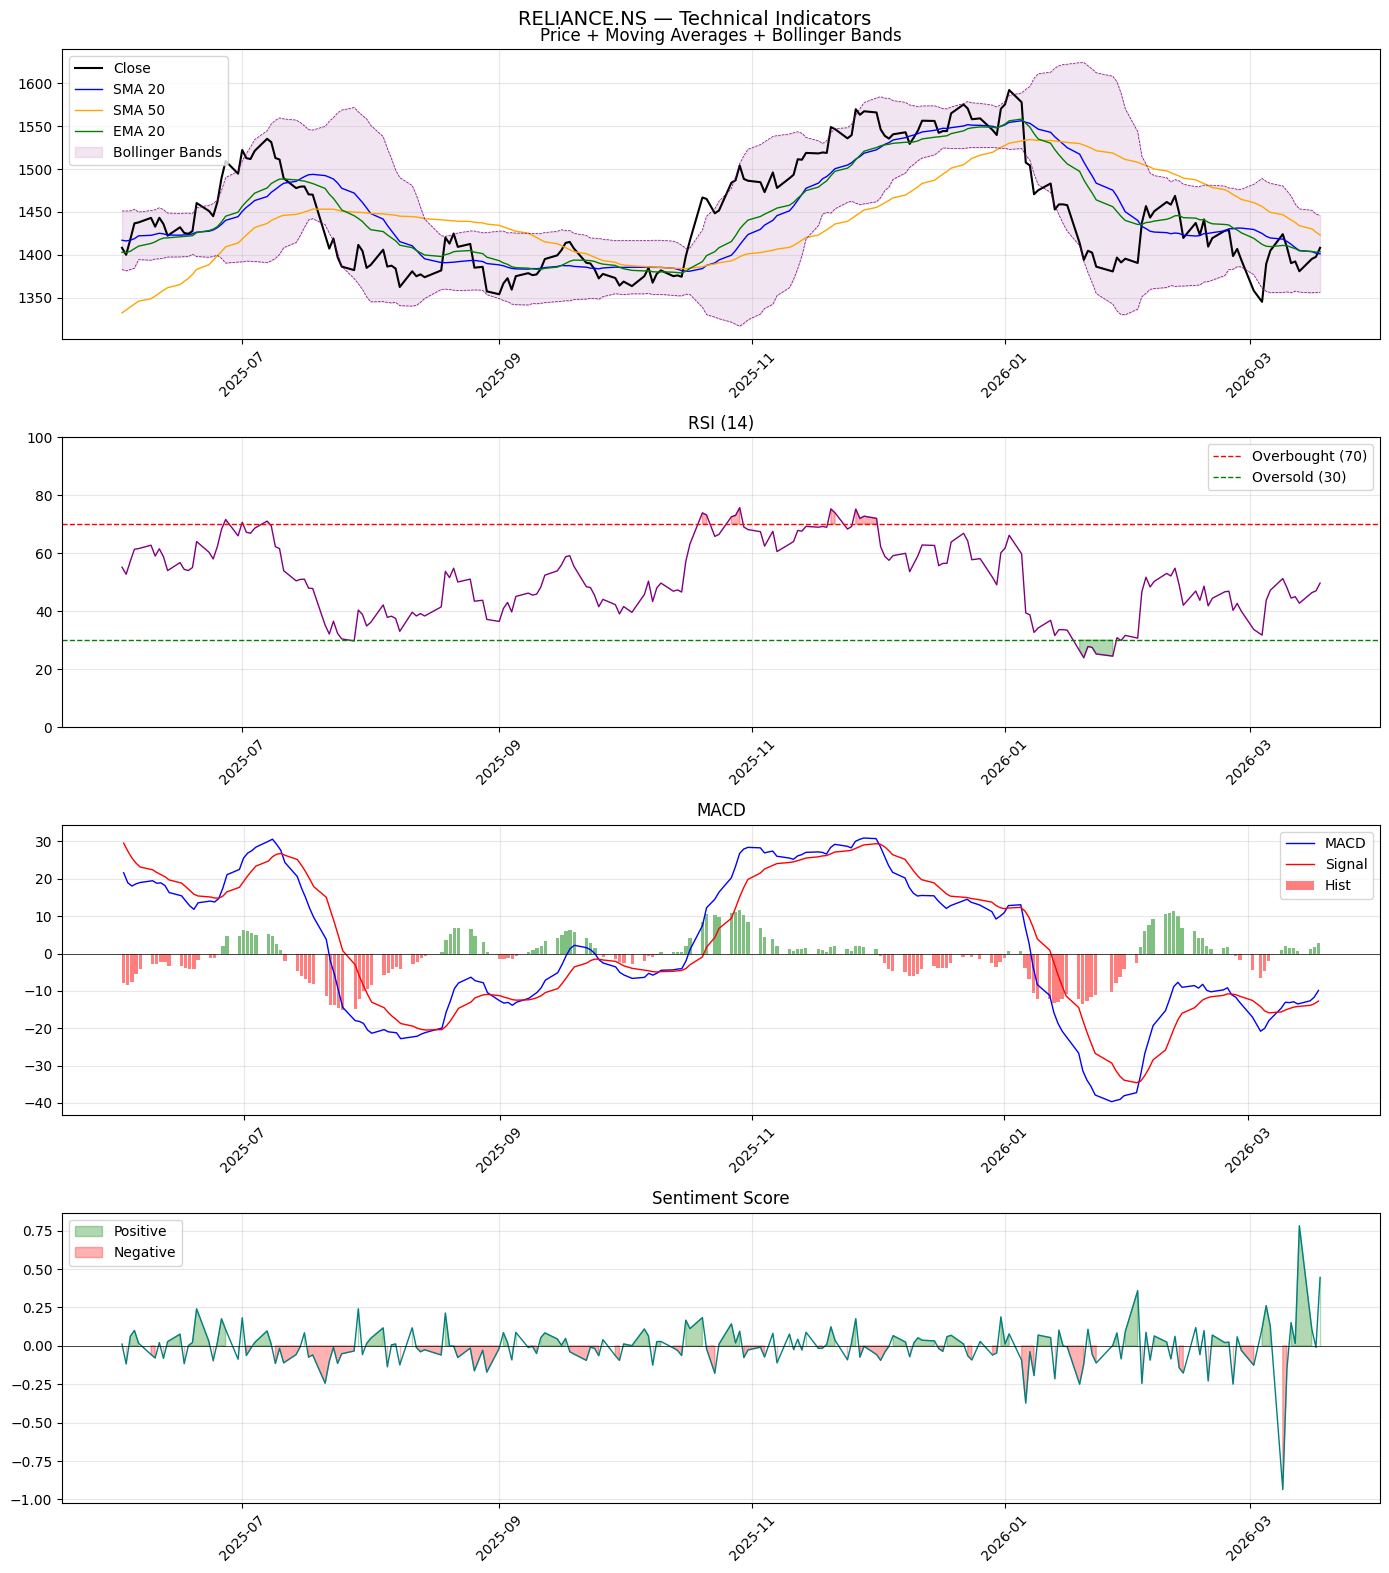

  ✓ Saved → plots/RELIANCE_NS_indicators.png


In [ ]:
def plot_indicators(ticker):
    df = all_data[ticker].tail(200)  # last 200 days for clarity

    fig, axes = plt.subplots(4, 1, figsize=(14, 16))
    fig.suptitle(f"{ticker} — Technical Indicators", fontsize=14)

    # price + moving averages + bollinger bands
    axes[0].plot(df.index, df["Close"],    label="Close",    color="black", linewidth=1.5)
    axes[0].plot(df.index, df["SMA_20"],   label="SMA 20",   color="blue",  linewidth=1)
    axes[0].plot(df.index, df["SMA_50"],   label="SMA 50",   color="orange",linewidth=1)
    axes[0].plot(df.index, df["EMA_20"],   label="EMA 20",   color="green", linewidth=1)
    axes[0].fill_between(df.index, df["BB_Upper"], df["BB_Lower"], alpha=0.1, color="purple", label="Bollinger Bands")
    axes[0].plot(df.index, df["BB_Upper"], color="purple", linewidth=0.5, linestyle="--")
    axes[0].plot(df.index, df["BB_Lower"], color="purple", linewidth=0.5, linestyle="--")
    axes[0].set_title("Price + Moving Averages + Bollinger Bands")
    axes[0].legend(loc="upper left")
    axes[0].grid(True, alpha=0.3)

    # RSI
    axes[1].plot(df.index, df["RSI_14"], color="purple", linewidth=1)
    axes[1].axhline(y=70, color="red",   linestyle="--", linewidth=1, label="Overbought (70)")
    axes[1].axhline(y=30, color="green", linestyle="--", linewidth=1, label="Oversold (30)")
    axes[1].fill_between(df.index, df["RSI_14"], 70, where=(df["RSI_14"] >= 70), color="red",   alpha=0.3)
    axes[1].fill_between(df.index, df["RSI_14"], 30, where=(df["RSI_14"] <= 30), color="green", alpha=0.3)
    axes[1].set_title("RSI (14)")
    axes[1].set_ylim(0, 100)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # MACD
    axes[2].plot(df.index, df["MACD"],        label="MACD",   color="blue",  linewidth=1)
    axes[2].plot(df.index, df["MACD_Signal"], label="Signal", color="red",   linewidth=1)
    axes[2].bar(df.index,  df["MACD_Hist"],   label="Hist",   color=["green" if v >= 0 else "red" for v in df["MACD_Hist"]], alpha=0.5)
    axes[2].axhline(y=0, color="black", linewidth=0.5)
    axes[2].set_title("MACD")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    # Sentiment
    axes[3].plot(df.index, df["Sentiment"], color="teal", linewidth=1)
    axes[3].fill_between(df.index, df["Sentiment"], 0,
                         where=(df["Sentiment"] >= 0), color="green", alpha=0.3, label="Positive")
    axes[3].fill_between(df.index, df["Sentiment"], 0,
                         where=(df["Sentiment"] < 0),  color="red",   alpha=0.3, label="Negative")
    axes[3].axhline(y=0, color="black", linewidth=0.5)
    axes[3].set_title("Sentiment Score")
    axes[3].legend()
    axes[3].grid(True, alpha=0.3)

    for ax in axes:
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

    plt.tight_layout()
    path = f"plots/{ticker.replace('.', '_')}_indicators.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  ✓ Saved → {path}")


for ticker in all_data.keys():
    plot_indicators(ticker)

Plotting loss curves for AAPL ...


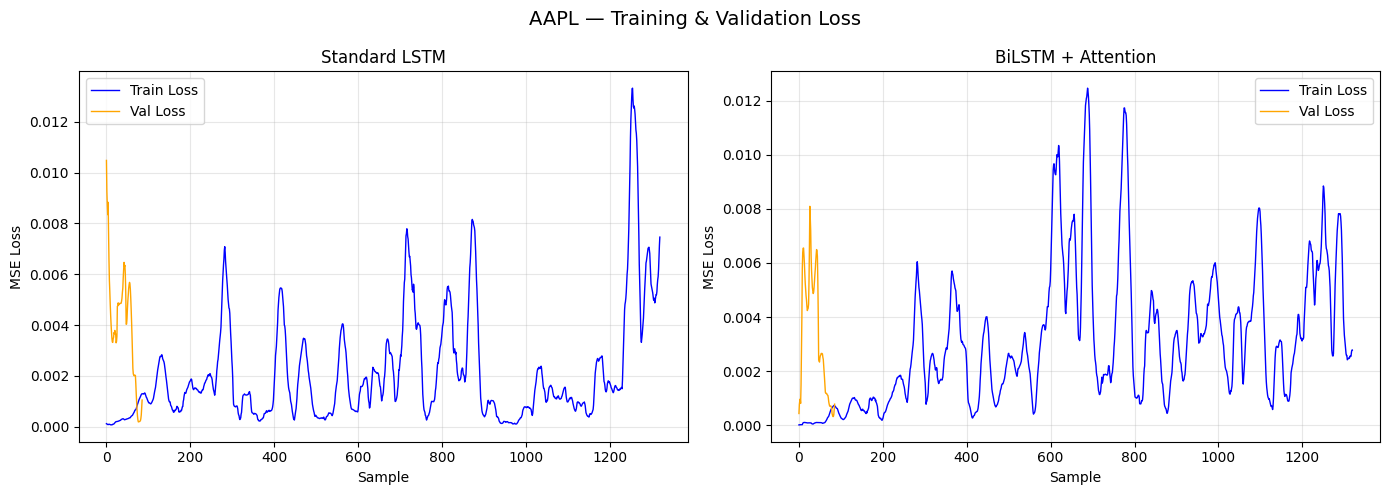

  ✓ Saved → plots/AAPL_loss_curves.png
Plotting loss curves for TSLA ...


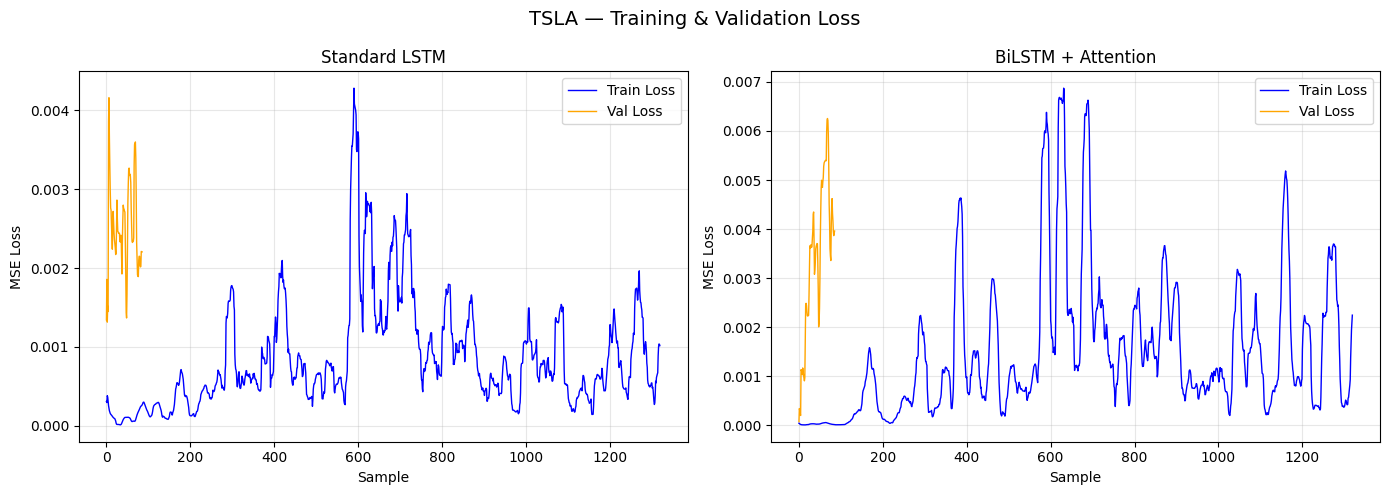

  ✓ Saved → plots/TSLA_loss_curves.png
Plotting loss curves for RELIANCE.NS ...


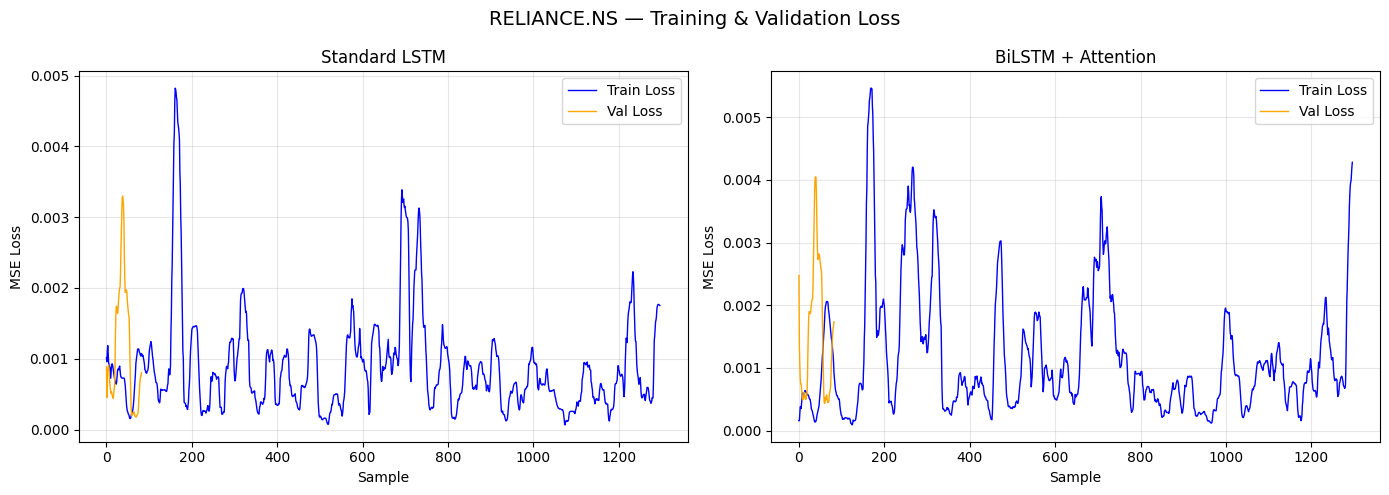

  ✓ Saved → plots/RELIANCE_NS_loss_curves.png
 Loss curves done!


In [ ]:
for ticker, data in processed_data.items():
    clean_ticker = ticker.replace(".", "_")
    print(f"Plotting loss curves for {ticker} ...")

    # load models
    lstm_model = tf.keras.models.load_model(f"models/{clean_ticker}_lstm.keras",     compile=False)
    adv_model  = tf.keras.models.load_model(f"models/{clean_ticker}_advanced.keras", compile=False)
    lstm_model.compile(optimizer="adam", loss="mse")
    adv_model.compile(optimizer="adam",  loss="mse")

    # get train/val data
    X_train = data["X_train"]
    y_train = data["y_train"]
    X_val   = data["X_val"]
    y_val   = data["y_val"]

    # run just 1 epoch to get history object structure
    # then evaluate on all batches to simulate loss curve
    # we calculate loss per batch manually instead
    train_preds = lstm_model.predict(X_train, verbose=0).flatten()
    val_preds   = lstm_model.predict(X_val,   verbose=0).flatten()

    # calculate rolling loss to simulate curve
    def rolling_mse(y_true, y_pred, window=20):
        losses = [(y_true[i] - y_pred[i])**2 for i in range(len(y_true))]
        return [np.mean(losses[max(0,i-window):i+1]) for i in range(len(losses))]

    lstm_train_loss = rolling_mse(y_train, train_preds)
    lstm_val_loss   = rolling_mse(y_val,   val_preds)

    adv_train_preds = adv_model.predict(X_train, verbose=0).flatten()
    adv_val_preds   = adv_model.predict(X_val,   verbose=0).flatten()
    adv_train_loss  = rolling_mse(y_train, adv_train_preds)
    adv_val_loss    = rolling_mse(y_val,   adv_val_preds)

    # plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{ticker} — Training & Validation Loss", fontsize=14)

    axes[0].plot(lstm_train_loss, label="Train Loss", color="blue",   linewidth=1)
    axes[0].plot(lstm_val_loss,   label="Val Loss",   color="orange", linewidth=1)
    axes[0].set_title("Standard LSTM")
    axes[0].set_xlabel("Sample")
    axes[0].set_ylabel("MSE Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(adv_train_loss, label="Train Loss", color="blue",   linewidth=1)
    axes[1].plot(adv_val_loss,   label="Val Loss",   color="orange", linewidth=1)
    axes[1].set_title("BiLSTM + Attention")
    axes[1].set_xlabel("Sample")
    axes[1].set_ylabel("MSE Loss")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    path = f"plots/{clean_ticker}_loss_curves.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  ✓ Saved → {path}")

print(" Loss curves done!")


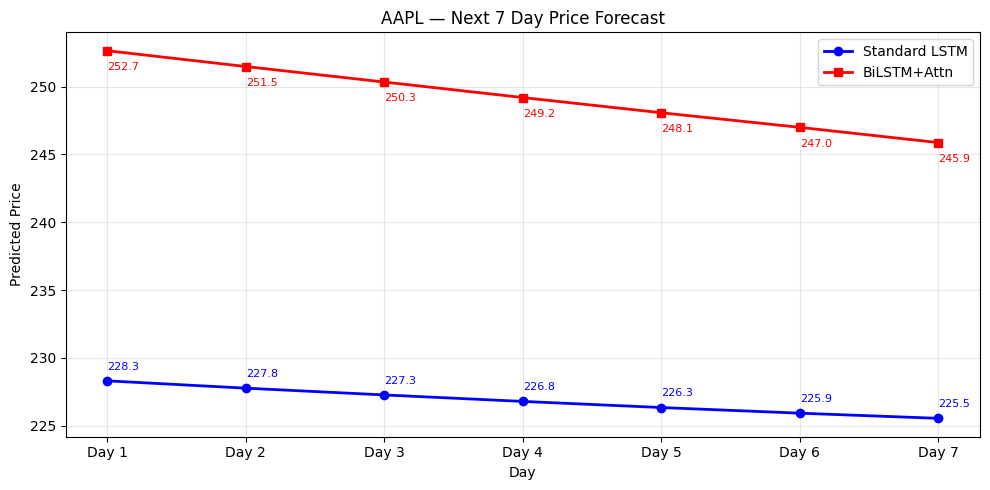

  ✓ Saved → plots/AAPL_forecast.png


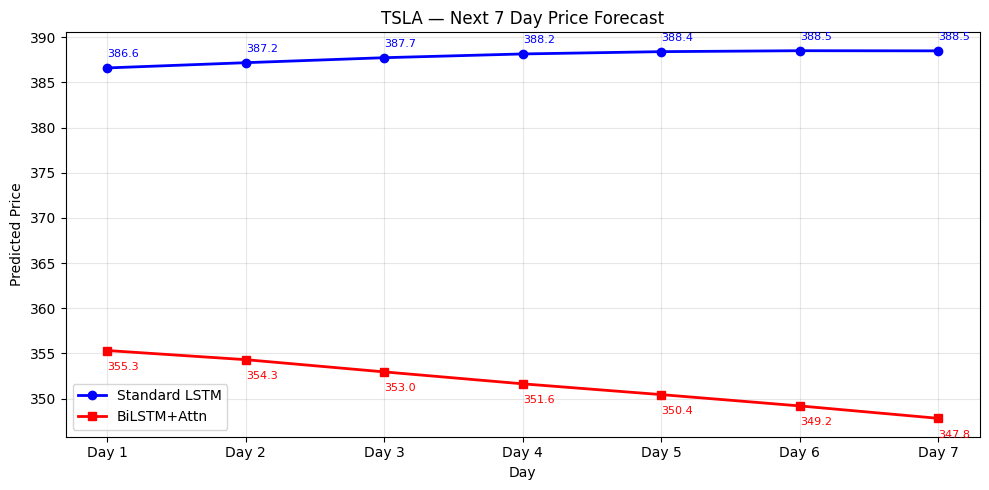

  ✓ Saved → plots/TSLA_forecast.png


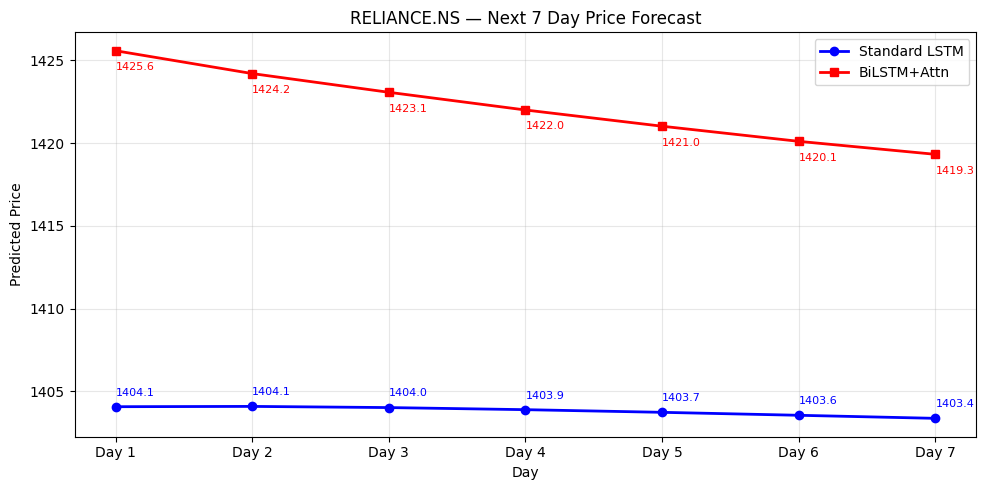

  ✓ Saved → plots/RELIANCE_NS_forecast.png


In [ ]:
def plot_next_7_days(ticker, metrics):
    next7_lstm = metrics["next_7_lstm"]
    next7_adv  = metrics["next_7_adv"]
    days       = [f"Day {i+1}" for i in range(7)]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(days, next7_lstm, marker="o", label="Standard LSTM",  color="blue",  linewidth=2)
    ax.plot(days, next7_adv,  marker="s", label="BiLSTM+Attn",    color="red",   linewidth=2)

    # add value labels
    for i, (v1, v2) in enumerate(zip(next7_lstm, next7_adv)):
        ax.annotate(f"{v1:.1f}", (days[i], v1), textcoords="offset points", xytext=(0, 8),  fontsize=8, color="blue")
        ax.annotate(f"{v2:.1f}", (days[i], v2), textcoords="offset points", xytext=(0, -14), fontsize=8, color="red")

    ax.set_title(f"{ticker} — Next 7 Day Price Forecast")
    ax.set_xlabel("Day")
    ax.set_ylabel("Predicted Price")
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    path = f"plots/{ticker.replace('.', '_')}_forecast.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  ✓ Saved → {path}")


for ticker, metrics in all_metrics.items():
    plot_next_7_days(ticker, metrics)


In [24]:
import requests

# test health
response = requests.get("http://127.0.0.1:5000/health")
print("Health:", response.json())

# test predict AAPL
response = requests.post(
    "http://127.0.0.1:5000/predict",
    json={"ticker": "AAPL", "model_type": "lstm"}
)
print("\nAAPL Prediction:", response.json())

# test predict TSLA
response = requests.post(
    "http://127.0.0.1:5000/predict",
    json={"ticker": "TSLA", "model_type": "advanced"}
)
print("\nTSLA Prediction:", response.json())

# test predict RELIANCE
response = requests.post(
    "http://127.0.0.1:5000/predict",
    json={"ticker": "RELIANCE.NS", "model_type": "lstm"}
)
print("\nRELIANCE Prediction:", response.json())

Health: {'message': 'Stock prediction API is running', 'models': ['AAPL', 'TSLA', 'RELIANCE_NS'], 'status': 'healthy'}

AAPL Prediction: {'currency': 'USD', 'model_type': 'lstm', 'predictions': [{'day': 1, 'label': 'Day 1', 'price': 241.94}, {'day': 2, 'label': 'Day 2', 'price': 241.45}, {'day': 3, 'label': 'Day 3', 'price': 240.98}, {'day': 4, 'label': 'Day 4', 'price': 240.53}, {'day': 5, 'label': 'Day 5', 'price': 240.14}, {'day': 6, 'label': 'Day 6', 'price': 239.79}, {'day': 7, 'label': 'Day 7', 'price': 239.48}], 'ticker': 'AAPL'}

TSLA Prediction: {'currency': 'USD', 'model_type': 'advanced', 'predictions': [{'day': 1, 'label': 'Day 1', 'price': 351.69}, {'day': 2, 'label': 'Day 2', 'price': 348.04}, {'day': 3, 'label': 'Day 3', 'price': 344.41}, {'day': 4, 'label': 'Day 4', 'price': 340.63}, {'day': 5, 'label': 'Day 5', 'price': 336.66}, {'day': 6, 'label': 'Day 6', 'price': 332.56}, {'day': 7, 'label': 'Day 7', 'price': 328.86}], 'ticker': 'TSLA'}

RELIANCE Prediction: {'curre